#ดึงข้อมูลอากาศรอบๆสระบุรีจากข้อมูลกรมอุตุนิยมวิทยาที่เก็บใน OGIMET
* https://github.com/feelfreelinux/ogimetdownloader
* https://github.com/iuiuiu-wayy/Ogimet
* ตัวอย่าง OGIMET ของลพบุรี https://ogimet.com/cgi-bin/gsynres?lang=en&ord=REV&ndays=30&ano=2026&mes=08&day=17&hora=06&ind=48426
* ตัวอย่างโค้ดในโปรแกรม R ไลบราลี่ Climate ที่จะดึงข้อมูล OGIMET มาใช้ได้ https://bczernecki.github.io/climate/
* ข้อมูลทดสอบ เวิร์ค!! ต้องปรับปรุงโค้ดให้รันแบบเลือกสถานีได้ เลือกช่วงเวลาได้

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libarchive-dev:amd64.
(Reading database ... 118422 files and directories currently installed.)
Preparing to unpack .../libarchive-dev_3.6.0-1ubuntu1.8_amd64.deb ...
Unpacking libarchive-dev:amd64 (3.6.0-1ubuntu1.8) ...
Setting up libarchive-dev:amd64 (3.6.0-1ubuntu1.8) ...
Processing triggers for man-db (2.10.2-1) ...
R version: R version 4.6.1 (2026-06-24) 
R library paths:
[1] "/usr/local/lib/R/site-library" "/usr/lib/R/site-library"      
[3] "/usr/lib/R/library"           

Installing missing dependencies: archive 
** Running ./configure
Found pkg-config cflags and libs!
PKG_CONFIG_PATH=
PKG_CFLAGS=
PKG_LIBS=-larchive 
g++ -std=gnu++20 -I"/usr/share/R/include" -DNDEBUG -Icpp11/include -I'/usr/lib/R/site-library/cli/include'     -fpic  -g -O2 -ffile-prefix-m

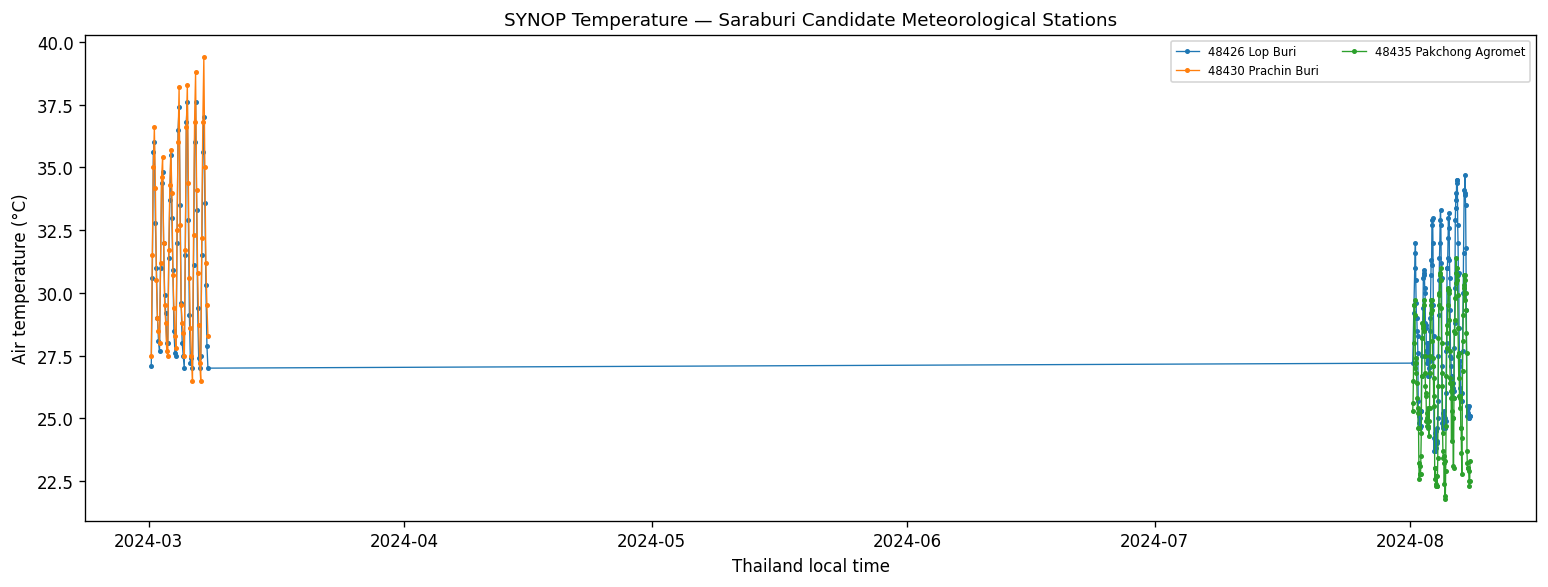

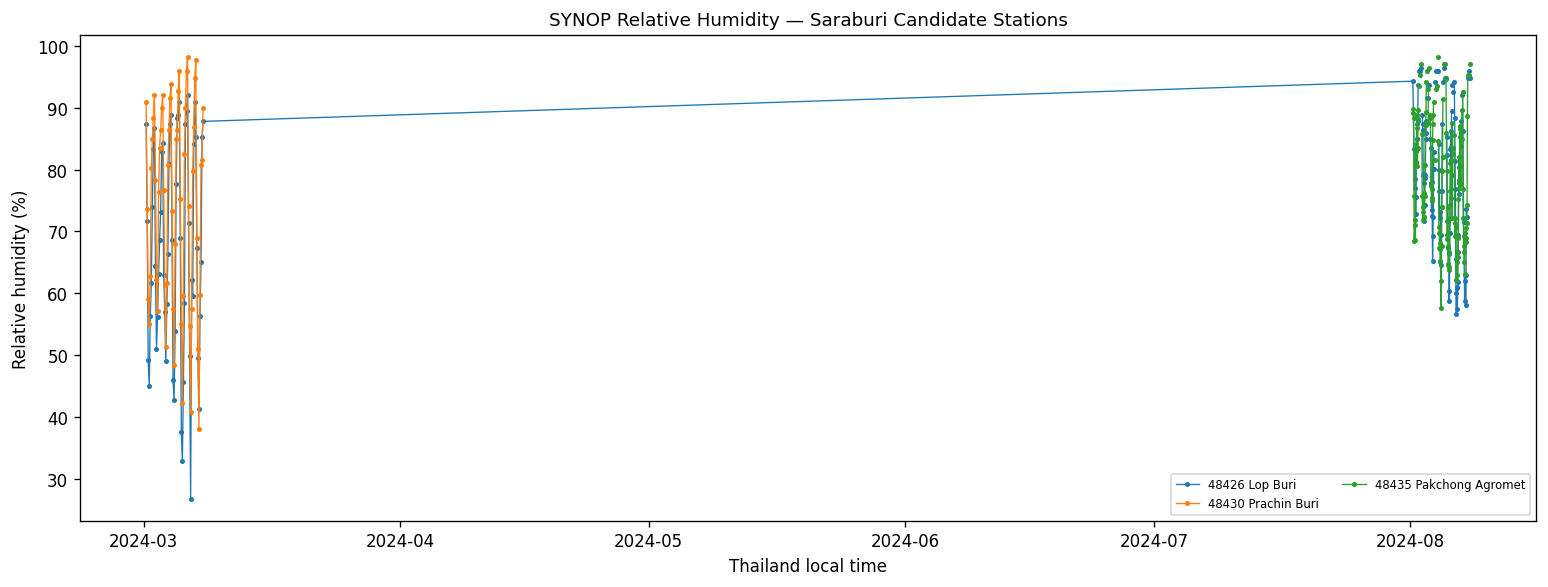

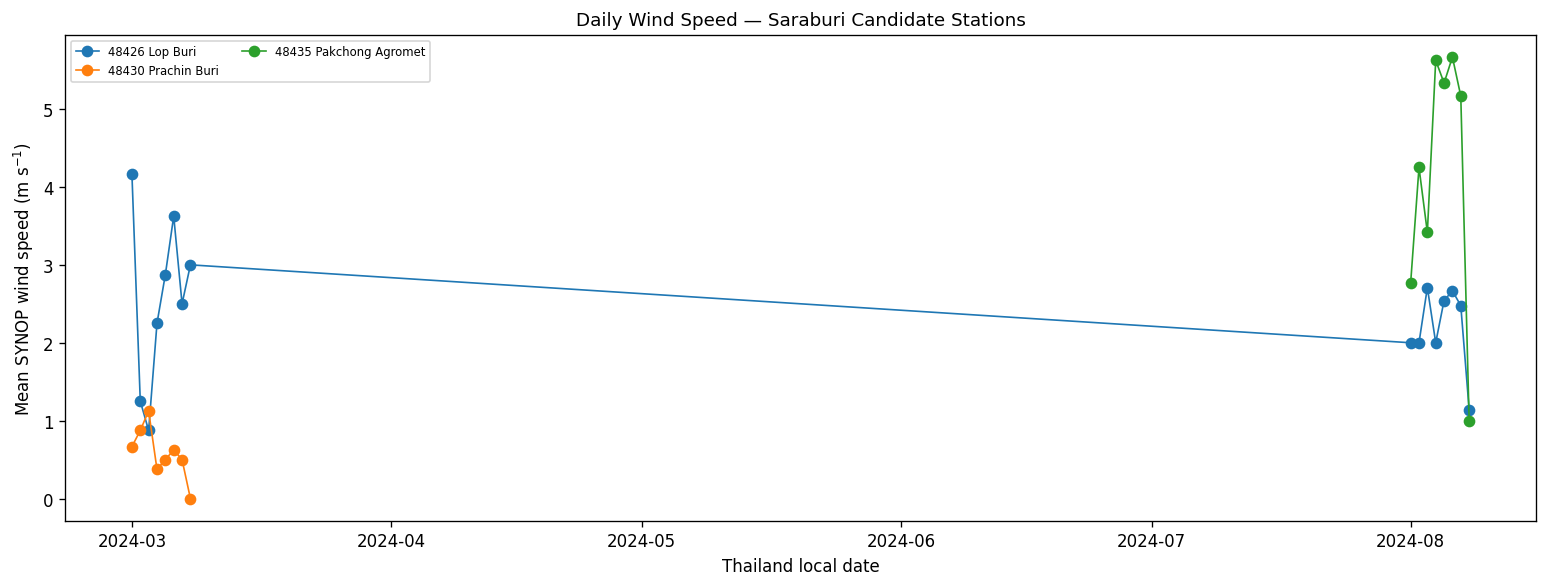

Saved:
/content/ogimet_saraburi_test/figures/FigA_synop_temperature_test.png
/content/ogimet_saraburi_test/figures/FigB_synop_RH_test.png
/content/ogimet_saraburi_test/figures/FigC_synop_wind_test.png

✅ Cell 13 completed.

INITIAL SYNOP TEST RECOMMENDATION
station             name  altitude_m  test_periods_available  mean_key_variable_score  mean_observations_per_test_period            initial_test_status
  48426         Lop Buri          10                       2                    0.883                              108.5          Strong test candidate
  48430     Prachin Buri           4                       1                    0.857                               56.0 Usable but inspect missingness
  48435 Pakchong Agromet         386                       1                    0.856                              168.0 Usable but inspect missingness
  48415        Ayutthaya           8                       0                      NaN                                NaN         No SY

In [1]:
# ====================================================================================
# COPY AS CODE CELL 00
# ====================================================================================
# =====================================================================
# CELL 00 — ROBUST INSTALLATION OF R + climate 1.4.x
#
# Run this in a FRESH Google Colab runtime.
# The cell installs R, required system libraries, the main CRAN imports,
# climate, and verifies that meteo_ogimet() is available.
# =====================================================================

import subprocess
from pathlib import Path

!apt-get -qq update
!apt-get -qq install -y \
    r-base r-base-dev build-essential \
    libcurl4-openssl-dev libssl-dev libxml2-dev \
    libarchive-dev libicu-dev

R_INSTALL = r"""
options(
  repos = c(CRAN = "https://cloud.r-project.org"),
  timeout = 1200
)

site_lib <- "/usr/local/lib/R/site-library"

if (!dir.exists(site_lib)) {
  dir.create(
    site_lib,
    recursive = TRUE,
    showWarnings = FALSE
  )
}

.libPaths(
  c(
    site_lib,
    .libPaths()
  )
)

cat("R version:", R.version.string, "\n")
cat("R library paths:\n")
print(.libPaths())

deps <- c(
  "archive",
  "curl",
  "data.table",
  "httr",
  "R6",
  "stringi"
)

missing_deps <- deps[
  !vapply(
    deps,
    requireNamespace,
    quietly = TRUE,
    FUN.VALUE = logical(1)
  )
]

if (length(missing_deps) > 0) {

  cat(
    "\nInstalling missing dependencies:",
    paste(
      missing_deps,
      collapse = ", "
    ),
    "\n"
  )

  install.packages(
    missing_deps,
    lib = site_lib,
    dependencies = c(
      "Depends",
      "Imports",
      "LinkingTo"
    )
  )
}

cat("\nInstalling climate from CRAN...\n")

install.packages(
  "climate",
  lib = site_lib,
  repos = "https://cloud.r-project.org",
  dependencies = FALSE
)

cat("\n--- INSTALLATION VERIFICATION ---\n")

ok <- requireNamespace(
  "climate",
  quietly = TRUE,
  lib.loc = site_lib
)

cat(
  "climate available:",
  ok,
  "\n"
)

if (!ok) {
  stop(
    "climate installation failed."
  )
}

library(
  climate,
  lib.loc = site_lib
)

cat(
  "climate version:",
  as.character(
    packageVersion(
      "climate"
    )
  ),
  "\n"
)

cat(
  "climate path:",
  find.package(
    "climate",
    lib.loc = site_lib
  ),
  "\n"
)

meteo_ok <- exists(
  "meteo_ogimet",
  where = asNamespace(
    "climate"
  )
)

cat(
  "meteo_ogimet exists:",
  meteo_ok,
  "\n"
)

if (!meteo_ok) {
  stop(
    "climate loaded, but meteo_ogimet() was not found."
  )
}

cat(
  "meteo_ogimet arguments:\n"
)

print(
  names(
    formals(
      climate::meteo_ogimet
    )
  )
)
"""

Path(
    "/content/install_climate_direct.R"
).write_text(
    R_INSTALL,
    encoding="utf-8"
)

proc = subprocess.run(
    [
        "Rscript",
        "/content/install_climate_direct.R"
    ],
    capture_output=True,
    text=True
)

print(
    proc.stdout
)

if proc.stderr:
    print(
        "\nR messages / warnings:"
    )
    print(
        proc.stderr
    )

print(
    "\nR return code:",
    proc.returncode
)

if proc.returncode != 0:
    raise RuntimeError(
        "Installation did not complete. "
        "Do NOT continue to Cell 00B."
    )

print(
    "\n✅ climate installation verified."
)


# ====================================================================================
# COPY AS CODE CELL 01
# ====================================================================================
# =====================================================================
# CELL 00B — INDEPENDENT VERIFICATION IN A NEW Rscript PROCESS
#
# This confirms that a separate R process can load climate from the same
# site library that the Ogimet worker will use.
# =====================================================================

import subprocess
from pathlib import Path

R_VERIFY = r"""
site_lib <- "/usr/local/lib/R/site-library"

.libPaths(
  c(
    site_lib,
    .libPaths()
  )
)

cat(
  "R version:",
  R.version.string,
  "\n"
)

cat(
  "R library paths:\n"
)

print(
  .libPaths()
)

ok <- requireNamespace(
  "climate",
  quietly = TRUE,
  lib.loc = site_lib
)

cat(
  "climate available:",
  ok,
  "\n"
)

if (!ok) {
  quit(
    status = 20
  )
}

library(
  climate,
  lib.loc = site_lib
)

cat(
  "climate version:",
  as.character(
    packageVersion(
      "climate"
    )
  ),
  "\n"
)

cat(
  "meteo_ogimet exists:",
  exists(
    "meteo_ogimet",
    where = asNamespace(
      "climate"
    )
  ),
  "\n"
)
"""

Path(
    "/content/verify_climate_direct.R"
).write_text(
    R_VERIFY,
    encoding="utf-8"
)

proc = subprocess.run(
    [
        "Rscript",
        "/content/verify_climate_direct.R"
    ],
    capture_output=True,
    text=True
)

print(
    proc.stdout
)

if proc.stderr:
    print(
        proc.stderr
    )

if proc.returncode != 0:
    raise RuntimeError(
        "Independent climate verification failed."
    )

print(
    "✅ Independent R process can load climate."
)


# ====================================================================================
# COPY AS CODE CELL 02
# ====================================================================================
# =====================================================================
# CELL 01 — PYTHON IMPORTS + TEST CONFIGURATION
# =====================================================================

import os
import json
import time
import math
import shutil
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = Path("/content/ogimet_saraburi_test")
RAW_DIR = OUT_DIR / "raw_synop"
FULL_DIR = OUT_DIR / "full_synop"
HTML_DIR = OUT_DIR / "html_daily"
FIG_DIR = OUT_DIR / "figures"
LOG_DIR = OUT_DIR / "logs"

for p in [OUT_DIR, RAW_DIR, FULL_DIR, HTML_DIR, FIG_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

STATIONS = pd.DataFrame([
    {
        "wmo": "48415",
        "name": "Ayutthaya",
        "latitude": 14 + 32/60 + 4/3600,
        "longitude": 100 + 43/60 + 29/3600,
        "altitude_m": 8,
        "role": "Primary nearest candidate"
    },
    {
        "wmo": "48426",
        "name": "Lop Buri",
        "latitude": 14 + 47/60 + 58/3600,
        "longitude": 100 + 37/60 + 41/3600,
        "altitude_m": 10,
        "role": "Long-record candidate"
    },
    {
        "wmo": "48435",
        "name": "Pakchong Agromet",
        "latitude": 14 + 38/60 + 30/3600,
        "longitude": 101 + 19/60 + 17/3600,
        "altitude_m": 386,
        "role": "Eastern / elevated sensitivity"
    },
    {
        "wmo": "48419",
        "name": "Pathumthani",
        "latitude": 14 + 6/60 + 57/3600,
        "longitude": 100 + 37/60 + 14/3600,
        "altitude_m": 6,
        "role": "Southwestern lowland sensitivity"
    },
    {
        "wmo": "48430",
        "name": "Prachin Buri",
        "latitude": 14 + 3/60 + 2/3600,
        "longitude": 101 + 22/60 + 9/3600,
        "altitude_m": 4,
        "role": "Eastern regional candidate"
    },
])

TEST_PERIODS = {
    "dry": ("2024-03-01", "2024-03-07"),
    "wet": ("2024-08-01", "2024-08-07"),
}

SMOKE_STATION = "48415"
SMOKE_START = "2024-03-01"
SMOKE_END = "2024-03-02"

HTML_VALIDATE = True
HTML_VALIDATE_STATIONS = ["48415", "48426"]
HTML_VALIDATE_START = "2024-03-01"
HTML_VALIDATE_END = "2024-03-03"

SYNOP_PAUSE_SECONDS = 2
LOCAL_TZ = "Asia/Bangkok"

VARIABLES_FOR_QA = [
    "t2m",
    "dpt2m",
    "rel_hum",
    "wd",
    "ws",
    "gust",
    "press",
    "slp",
    "precip",
]

FIG_DPI = 300

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": FIG_DPI,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

STATIONS.to_csv(
    OUT_DIR / "candidate_synop_stations.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Candidate stations:")
print(STATIONS.to_string(index=False))
print("\nTest periods:", TEST_PERIODS)
print("\nOutput directory:", OUT_DIR)

print("\n✅ Cell 01 completed.")


# ====================================================================================
# COPY AS CODE CELL 03
# ====================================================================================
# =====================================================================
# CELL 02 — CREATE R OGIMET WORKER
# =====================================================================

R_WORKER = Path("/content/ogimet_worker.R")

R_WORKER.write_text(r"""
site_lib <- "/usr/local/lib/R/site-library"
.libPaths(c(site_lib, .libPaths()))

args <- commandArgs(trailingOnly = TRUE)

if (length(args) < 6) {
  stop("Usage: Rscript ogimet_worker.R MODE STATION START END OUT1 OUT2")
}

mode <- args[1]
station <- args[2]
start_date <- args[3]
end_date <- args[4]
out1 <- args[5]
out2 <- args[6]

suppressPackageStartupMessages(
  library(
    climate,
    lib.loc = site_lib
  )
)

safe_write <- function(x, path) {
  if (is.null(x)) return(FALSE)
  if (!is.data.frame(x)) x <- as.data.frame(x)
  write.csv(x, path, row.names = FALSE, na = "")
  TRUE
}

if (mode == "synop") {

  result <- tryCatch(
    meteo_ogimet(
      interval = "hourly",
      date = c(start_date, end_date),
      station = station,
      source = "synop",
      return_list = TRUE,
      allow_failure = TRUE
    ),
    error = function(e) {
      message("ERROR: ", conditionMessage(e))
      NULL
    }
  )

  if (is.null(result)) {
    quit(status = 2)
  }

  compact <- result$data
  full <- result$full

  if (is.null(compact) || nrow(compact) == 0) {
    quit(status = 3)
  }

  if ("date" %in% names(compact)) {
    compact$date_utc_iso <- format(
      as.POSIXct(compact$date, tz = "UTC"),
      "%Y-%m-%dT%H:%M:%SZ",
      tz = "UTC"
    )
  }

  if (!is.null(full) && nrow(full) > 0) {
    if ("Date" %in% names(full)) {
      full$date_utc_iso <- format(
        as.POSIXct(full$Date, tz = "UTC"),
        "%Y-%m-%dT%H:%M:%SZ",
        tz = "UTC"
      )
    }
  }

  ok1 <- safe_write(compact, out1)
  ok2 <- safe_write(full, out2)

  cat("SYNOP compact rows:", nrow(compact), "\n")
  cat("SYNOP full rows:", ifelse(is.null(full), 0, nrow(full)), "\n")

  if (!ok1) quit(status = 4)

} else if (mode == "html") {

  result <- tryCatch(
    meteo_ogimet(
      interval = "daily",
      date = c(start_date, end_date),
      station = station,
      source = "html",
      allow_failure = TRUE
    ),
    error = function(e) {
      message("ERROR: ", conditionMessage(e))
      NULL
    }
  )

  if (is.null(result) || nrow(result) == 0) {
    quit(status = 5)
  }

  safe_write(result, out1)
  cat("HTML daily rows:", nrow(result), "\n")

} else {
  stop("Unknown MODE: ", mode)
}
""", encoding="utf-8")

print("R worker saved to:", R_WORKER)
print(R_WORKER.read_text(encoding="utf-8")[:1800])

print("\n✅ Cell 02 completed.")


# ====================================================================================
# COPY AS CODE CELL 04
# ====================================================================================
# =====================================================================
# CELL 03 — PYTHON DOWNLOAD HELPERS + LOGGING
# =====================================================================

def run_r_worker(
    mode,
    station,
    start_date,
    end_date,
    out1,
    out2="/content/unused.csv",
    timeout_seconds=240
):
    cmd = [
        "Rscript",
        str(R_WORKER),
        str(mode),
        str(station),
        str(start_date),
        str(end_date),
        str(out1),
        str(out2),
    ]

    started = time.time()

    try:
        proc = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            timeout=timeout_seconds
        )

        status = "success" if proc.returncode == 0 else "failed"

        return {
            "mode": mode,
            "station": str(station),
            "start": start_date,
            "end": end_date,
            "status": status,
            "returncode": proc.returncode,
            "elapsed_s": round(time.time() - started, 1),
            "stdout": proc.stdout.strip(),
            "stderr": proc.stderr.strip(),
            "out1": str(out1),
            "out2": str(out2),
        }

    except subprocess.TimeoutExpired as e:
        return {
            "mode": mode,
            "station": str(station),
            "start": start_date,
            "end": end_date,
            "status": "timeout",
            "returncode": None,
            "elapsed_s": round(time.time() - started, 1),
            "stdout": str(e.stdout or ""),
            "stderr": str(e.stderr or ""),
            "out1": str(out1),
            "out2": str(out2),
        }


download_logs = []

def download_synop_period(station, label, start_date, end_date, overwrite=False):

    compact_file = RAW_DIR / f"{station}_{label}_{start_date}_{end_date}_compact.csv"
    full_file = FULL_DIR / f"{station}_{label}_{start_date}_{end_date}_full.csv"

    if compact_file.exists() and not overwrite:
        print(f"SKIP existing: {compact_file.name}")
        return compact_file, full_file

    print(f"Downloading SYNOP {station} | {label} | {start_date} to {end_date}")

    log = run_r_worker(
        mode="synop",
        station=station,
        start_date=start_date,
        end_date=end_date,
        out1=compact_file,
        out2=full_file,
        timeout_seconds=240
    )

    download_logs.append(log)

    print("  status:", log["status"])
    print("  elapsed:", log["elapsed_s"], "s")

    if log["stdout"]:
        print("  R:", log["stdout"][:500])

    if log["stderr"]:
        print("  warning/error:", log["stderr"][:500])

    return compact_file, full_file


def save_download_log():
    if download_logs:
        pd.DataFrame(download_logs).to_csv(
            LOG_DIR / "ogimet_download_log.csv",
            index=False,
            encoding="utf-8-sig"
        )

print("✅ Cell 03 completed.")


# ====================================================================================
# COPY AS CODE CELL 05
# ====================================================================================
# =====================================================================
# CELL 04 — SMOKE TEST: 48415 AYUTTHAYA, 2 DAYS
# =====================================================================

smoke_compact, smoke_full = download_synop_period(
    station=SMOKE_STATION,
    label="smoke",
    start_date=SMOKE_START,
    end_date=SMOKE_END,
    overwrite=True
)

save_download_log()

if smoke_compact.exists():
    smoke_df = pd.read_csv(smoke_compact)

    print("\nSmoke-test columns:")
    print(smoke_df.columns.tolist())

    print("\nFirst rows:")
    print(smoke_df.head(12).to_string(index=False))

    print("\nRows:", len(smoke_df))

else:
    raise RuntimeError(
        "Smoke test failed: no compact SYNOP CSV was created. "
        "STOP here. Do not run the multi-station download."
    )

print("\n✅ Cell 04 completed.")


# ====================================================================================
# COPY AS CODE CELL 06
# ====================================================================================
# =====================================================================
# CELL 05 — DOWNLOAD RAW SYNOP FOR ALL 5 STATIONS:
#           DRY + WET TEST PERIODS
# =====================================================================

synop_files = []

for period_label, (start_date, end_date) in TEST_PERIODS.items():

    for station in STATIONS["wmo"]:

        compact_file, full_file = download_synop_period(
            station=station,
            label=period_label,
            start_date=start_date,
            end_date=end_date,
            overwrite=False
        )

        synop_files.append({
            "period": period_label,
            "station": station,
            "start": start_date,
            "end": end_date,
            "compact_file": str(compact_file),
            "full_file": str(full_file),
            "compact_exists": compact_file.exists(),
            "full_exists": full_file.exists(),
        })

        time.sleep(SYNOP_PAUSE_SECONDS)

save_download_log()

synop_file_index = pd.DataFrame(synop_files)

synop_file_index.to_csv(
    OUT_DIR / "synop_file_index.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSYNOP file index:")
print(synop_file_index.to_string(index=False))

print("\n✅ Cell 05 completed.")


# ====================================================================================
# COPY AS CODE CELL 07
# ====================================================================================
# =====================================================================
# CELL 06 — READ + COMBINE COMPACT SYNOP FILES
#           UTC → ASIA/BANGKOK
# =====================================================================

compact_parts = []

for _, row in synop_file_index.iterrows():

    path = Path(row["compact_file"])

    if not path.exists():
        continue

    try:
        d = pd.read_csv(path)

        if d.empty:
            continue

        d["test_period"] = row["period"]
        d["requested_station"] = str(row["station"])

        if "date_utc_iso" in d.columns:
            d["datetime_utc"] = pd.to_datetime(
                d["date_utc_iso"],
                utc=True,
                errors="coerce"
            )

        elif "date" in d.columns:
            d["datetime_utc"] = pd.to_datetime(
                d["date"],
                utc=True,
                errors="coerce"
            )

        else:
            raise RuntimeError(
                f"No date column found in {path.name}"
            )

        d["datetime_local"] = (
            d["datetime_utc"]
            .dt.tz_convert(LOCAL_TZ)
        )

        d["date_local"] = (
            d["datetime_local"]
            .dt.date
        )

        d["hour_local"] = (
            d["datetime_local"]
            .dt.hour
        )

        compact_parts.append(d)

    except Exception as e:
        print("FAILED reading:", path.name, repr(e))

if not compact_parts:
    raise RuntimeError(
        "No compact SYNOP files were successfully loaded. "
        "Review Cells 04–05."
    )

synop_hourly = pd.concat(
    compact_parts,
    ignore_index=True
)

if "station" in synop_hourly.columns:
    synop_hourly["station"] = (
        synop_hourly["station"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(5)
    )
else:
    synop_hourly["station"] = (
        synop_hourly["requested_station"]
        .astype(str)
        .str.zfill(5)
    )

for col in VARIABLES_FOR_QA + ["tmax", "tmin", "Nt", "Nh", "visibility", "snow"]:
    if col in synop_hourly.columns:
        synop_hourly[col] = pd.to_numeric(
            synop_hourly[col],
            errors="coerce"
        )

synop_hourly = synop_hourly.merge(
    STATIONS[
        [
            "wmo",
            "name",
            "latitude",
            "longitude",
            "altitude_m",
            "role"
        ]
    ],
    left_on="station",
    right_on="wmo",
    how="left"
)

synop_hourly.to_csv(
    OUT_DIR / "combined_synop_hourly_localtime.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nCombined SYNOP rows:", len(synop_hourly))
print(
    "UTC span:",
    synop_hourly["datetime_utc"].min(),
    "to",
    synop_hourly["datetime_utc"].max()
)
print(
    "Thailand-local span:",
    synop_hourly["datetime_local"].min(),
    "to",
    synop_hourly["datetime_local"].max()
)

print("\nRows by period/station:")
print(
    synop_hourly
    .groupby(["test_period", "station"])
    .size()
    .rename("n_rows")
    .reset_index()
    .to_string(index=False)
)

print("\n✅ Cell 06 completed.")


# ====================================================================================
# COPY AS CODE CELL 08
# ====================================================================================
# =====================================================================
# CELL 07 — SUBDAILY QA:
#           OBSERVATIONS/DAY + VARIABLE COMPLETENESS
# =====================================================================

qa_rows = []

for keys, g in synop_hourly.groupby(
    ["test_period", "station", "date_local"],
    sort=True
):
    period, station, date_local = keys

    row = {
        "test_period": period,
        "station": station,
        "date_local": date_local,
        "n_synop_obs": len(g),
        "n_unique_local_hours": g["hour_local"].nunique(),
    }

    for col in VARIABLES_FOR_QA:

        if col in g.columns:
            valid_n = int(
                g[col]
                .notna()
                .sum()
            )

            row[f"{col}_valid_n"] = valid_n
            row[f"{col}_valid_fraction"] = (
                valid_n / len(g)
                if len(g) > 0
                else np.nan
            )

        else:
            row[f"{col}_valid_n"] = 0
            row[f"{col}_valid_fraction"] = np.nan

    qa_rows.append(row)

daily_subdaily_qa = pd.DataFrame(
    qa_rows
)

daily_subdaily_qa.to_csv(
    OUT_DIR / "synop_subdaily_QA.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nOBSERVATIONS PER DAY — SUMMARY")
print("=" * 110)

print(
    daily_subdaily_qa
    .groupby(["test_period", "station"])["n_synop_obs"]
    .agg(["count", "min", "median", "max", "mean"])
    .round(2)
    .reset_index()
    .to_string(index=False)
)

print("\nVARIABLE COMPLETENESS — MEAN FRACTION")
print("=" * 130)

fraction_cols = [
    c for c in daily_subdaily_qa.columns
    if c.endswith("_valid_fraction")
]

print(
    daily_subdaily_qa
    .groupby(["test_period", "station"])[fraction_cols]
    .mean()
    .round(3)
    .reset_index()
    .to_string(index=False)
)

print("\n✅ Cell 07 completed.")


# ====================================================================================
# COPY AS CODE CELL 09
# ====================================================================================
# =====================================================================
# CELL 08 — WIND VECTOR CALCULATION + DAILY AGGREGATION
# =====================================================================

synop_hourly["wind_u"] = np.nan
synop_hourly["wind_v"] = np.nan

if (
    "wd" in synop_hourly.columns
    and
    "ws" in synop_hourly.columns
):

    valid_wind = (
        synop_hourly["wd"].notna()
        &
        synop_hourly["ws"].notna()
    )

    theta = np.deg2rad(
        synop_hourly.loc[
            valid_wind,
            "wd"
        ]
    )

    ws = synop_hourly.loc[
        valid_wind,
        "ws"
    ]

    synop_hourly.loc[
        valid_wind,
        "wind_u"
    ] = (
        -ws
        *
        np.sin(theta)
    )

    synop_hourly.loc[
        valid_wind,
        "wind_v"
    ] = (
        -ws
        *
        np.cos(theta)
    )


def resultant_wind_direction(u_mean, v_mean):

    if (
        not np.isfinite(u_mean)
        or
        not np.isfinite(v_mean)
    ):
        return np.nan

    return (
        np.degrees(
            np.arctan2(
                -u_mean,
                -v_mean
            )
        )
        + 360
    ) % 360


daily_rows = []

for keys, g in synop_hourly.groupby(
    ["test_period", "station", "date_local"],
    sort=True
):
    period, station, date_local = keys

    def mean_if(col):
        return (
            g[col].mean()
            if col in g.columns
            else np.nan
        )

    def min_if(col):
        return (
            g[col].min()
            if col in g.columns
            else np.nan
        )

    def max_if(col):
        return (
            g[col].max()
            if col in g.columns
            else np.nan
        )

    u_mean = mean_if("wind_u")
    v_mean = mean_if("wind_v")

    ws_resultant = (
        np.sqrt(
            u_mean**2
            +
            v_mean**2
        )
        if (
            np.isfinite(u_mean)
            and
            np.isfinite(v_mean)
        )
        else np.nan
    )

    precip_sum_naive = (
        g["precip"].sum(min_count=1)
        if "precip" in g.columns
        else np.nan
    )

    precip_max_report = (
        g["precip"].max()
        if "precip" in g.columns
        else np.nan
    )

    daily_rows.append({
        "test_period": period,
        "station": station,
        "date_local": pd.to_datetime(date_local),
        "n_synop_obs": len(g),

        "t_mean": mean_if("t2m"),
        "t_min_observed": min_if("t2m"),
        "t_max_observed": max_if("t2m"),

        "td_mean": mean_if("dpt2m"),
        "rh_mean": mean_if("rel_hum"),

        "ws_scalar_mean_ms": mean_if("ws"),
        "ws_max_ms": max_if("ws"),
        "gust_max_ms": max_if("gust"),

        "u_mean_ms": u_mean,
        "v_mean_ms": v_mean,
        "ws_resultant_ms": ws_resultant,
        "wd_resultant_deg": resultant_wind_direction(
            u_mean,
            v_mean
        ),

        "station_pressure_mean_hpa": mean_if("press"),
        "slp_mean_hpa": mean_if("slp"),

        "precip_sum_naive_DIAGNOSTIC": precip_sum_naive,
        "precip_max_report_DIAGNOSTIC": precip_max_report,

        "cloud_cover_mean_okta": mean_if("Nt"),
        "visibility_mean": mean_if("visibility"),
    })

synop_daily = pd.DataFrame(
    daily_rows
)

synop_daily = synop_daily.merge(
    STATIONS[
        [
            "wmo",
            "name",
            "latitude",
            "longitude",
            "altitude_m",
            "role"
        ]
    ],
    left_on="station",
    right_on="wmo",
    how="left"
)

synop_daily.to_csv(
    OUT_DIR / "synop_daily_derived.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nDerived daily meteorology:")
print(
    synop_daily
    .head(25)
    .round(2)
    .to_string(index=False)
)

print(
    "\n⚠️ Raw SYNOP precipitation aggregation remains DIAGNOSTIC only "
    "until checked against daily summaries / precipitation-time metadata."
)

print("\n✅ Cell 08 completed.")


# ====================================================================================
# COPY AS CODE CELL 10
# ====================================================================================
# =====================================================================
# CELL 09 — OPTIONAL SHORT DAILY HTML VALIDATION
# =====================================================================

html_logs = []

if HTML_VALIDATE:

    for station in HTML_VALIDATE_STATIONS:

        out_file = (
            HTML_DIR
            /
            f"{station}_{HTML_VALIDATE_START}_{HTML_VALIDATE_END}_daily_html.csv"
        )

        print(
            f"Downloading daily HTML validation: "
            f"{station} | {HTML_VALIDATE_START} to {HTML_VALIDATE_END}"
        )

        log = run_r_worker(
            mode="html",
            station=station,
            start_date=HTML_VALIDATE_START,
            end_date=HTML_VALIDATE_END,
            out1=out_file,
            out2="/content/unused.csv",
            timeout_seconds=420
        )

        html_logs.append(log)

        print(
            "  status:",
            log["status"],
            "| elapsed:",
            log["elapsed_s"],
            "s"
        )

        if log["stdout"]:
            print("  R:", log["stdout"][:500])

        if log["stderr"]:
            print("  warning/error:", log["stderr"][:500])

else:
    print("HTML validation disabled.")

if html_logs:

    pd.DataFrame(
        html_logs
    ).to_csv(
        LOG_DIR / "ogimet_html_validation_log.csv",
        index=False,
        encoding="utf-8-sig"
    )

print("\n✅ Cell 09 completed.")


# ====================================================================================
# COPY AS CODE CELL 11
# ====================================================================================
# =====================================================================
# CELL 10 — RAW-SYNOP-DERIVED DAILY vs HTML DAILY VALIDATION
# =====================================================================

def find_column(columns, candidates):

    norm = {
        str(c)
        .lower()
        .replace("_", "")
        .replace(".", "")
        .replace(" ", ""):
        c
        for c in columns
    }

    for candidate in candidates:

        key = (
            candidate
            .lower()
            .replace("_", "")
            .replace(".", "")
            .replace(" ", "")
        )

        if key in norm:
            return norm[key]

    return None


html_parts = []

for path in sorted(
    HTML_DIR.glob(
        "*_daily_html.csv"
    )
):

    try:
        h = pd.read_csv(path)

        if h.empty:
            continue

        station_from_file = path.name.split("_")[0]

        station_col = find_column(
            h.columns,
            ["station_ID", "stationID", "station"]
        )

        date_col = find_column(
            h.columns,
            ["Date", "date"]
        )

        tmean_col = find_column(
            h.columns,
            ["TemperatureCAvg", "TempCAvg"]
        )

        rh_col = find_column(
            h.columns,
            ["HrAvg", "RHAvg", "rel_hum"]
        )

        wind_col = find_column(
            h.columns,
            ["WindkmhInt", "WindInt", "Windkmh", "wind_speed"]
        )

        precip_col = find_column(
            h.columns,
            ["Precmm", "Prec_mm", "precip"]
        )

        press_col = find_column(
            h.columns,
            ["PresslevHp", "PressHp", "P0hPa", "pressure"]
        )

        out = pd.DataFrame()

        out["station"] = (
            h[station_col]
            .astype(str)
            .str.replace(
                r"\.0$",
                "",
                regex=True
            )
            .str.zfill(5)
            if station_col is not None
            else station_from_file
        )

        out["date_local"] = pd.to_datetime(
            h[date_col],
            errors="coerce"
        )

        out["html_t_mean"] = (
            pd.to_numeric(
                h[tmean_col],
                errors="coerce"
            )
            if tmean_col is not None
            else np.nan
        )

        out["html_rh_mean"] = (
            pd.to_numeric(
                h[rh_col],
                errors="coerce"
            )
            if rh_col is not None
            else np.nan
        )

        out["html_wind_mean_kmh"] = (
            pd.to_numeric(
                h[wind_col],
                errors="coerce"
            )
            if wind_col is not None
            else np.nan
        )

        out["html_precip_mm"] = (
            pd.to_numeric(
                h[precip_col],
                errors="coerce"
            )
            if precip_col is not None
            else np.nan
        )

        out["html_pressure_hpa"] = (
            pd.to_numeric(
                h[press_col],
                errors="coerce"
            )
            if press_col is not None
            else np.nan
        )

        out["source_file"] = path.name

        html_parts.append(out)

        print("\nHTML file:", path.name)
        print("Columns:", h.columns.tolist())

    except Exception as e:
        print(
            "FAILED reading",
            path.name,
            repr(e)
        )

if html_parts:

    html_daily = pd.concat(
        html_parts,
        ignore_index=True
    )

    raw_validation = synop_daily[
        (
            synop_daily["date_local"]
            >=
            pd.Timestamp(HTML_VALIDATE_START)
        )
        &
        (
            synop_daily["date_local"]
            <=
            pd.Timestamp(HTML_VALIDATE_END)
        )
        &
        (
            synop_daily["station"]
            .isin(HTML_VALIDATE_STATIONS)
        )
    ].copy()

    validation_compare = raw_validation.merge(
        html_daily,
        on=["station", "date_local"],
        how="outer"
    )

    validation_compare["raw_ws_mean_kmh"] = (
        validation_compare["ws_scalar_mean_ms"] * 3.6
    )

    validation_compare["temperature_diff_raw_minus_html"] = (
        validation_compare["t_mean"]
        -
        validation_compare["html_t_mean"]
    )

    validation_compare["rh_diff_raw_minus_html"] = (
        validation_compare["rh_mean"]
        -
        validation_compare["html_rh_mean"]
    )

    validation_compare["wind_kmh_diff_raw_minus_html"] = (
        validation_compare["raw_ws_mean_kmh"]
        -
        validation_compare["html_wind_mean_kmh"]
    )

    validation_compare.to_csv(
        OUT_DIR / "raw_vs_html_daily_validation.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print("\nRAW vs HTML DAILY VALIDATION")
    print("=" * 140)

    cols_show = [
        "station",
        "date_local",
        "t_mean",
        "html_t_mean",
        "temperature_diff_raw_minus_html",
        "rh_mean",
        "html_rh_mean",
        "raw_ws_mean_kmh",
        "html_wind_mean_kmh",
        "html_precip_mm",
        "precip_sum_naive_DIAGNOSTIC",
    ]

    cols_show = [
        c
        for c in cols_show
        if c in validation_compare.columns
    ]

    print(
        validation_compare[
            cols_show
        ]
        .round(2)
        .to_string(index=False)
    )

else:
    html_daily = pd.DataFrame()
    validation_compare = pd.DataFrame()

    print(
        "No HTML validation data available. "
        "This does not prevent SYNOP testing."
    )

print(
    "\nDo NOT accept raw SYNOP precipitation as a daily total "
    "until the precipitation accumulation metadata have been verified."
)

print("\n✅ Cell 10 completed.")


# ====================================================================================
# COPY AS CODE CELL 12
# ====================================================================================
# =====================================================================
# CELL 11 — FULL SYNOP PARSER OUTPUT + PRECIPITATION DIAGNOSTICS
# =====================================================================

full_parts = []

for _, row in synop_file_index.iterrows():

    path = Path(
        row[
            "full_file"
        ]
    )

    if not path.exists():
        continue

    try:
        f = pd.read_csv(
            path
        )

        if f.empty:
            continue

        f[
            "test_period"
        ] = row[
            "period"
        ]

        f[
            "requested_station"
        ] = str(
            row[
                "station"
            ]
        )

        if "date_utc_iso" in f.columns:

            f[
                "datetime_utc"
            ] = pd.to_datetime(
                f[
                    "date_utc_iso"
                ],
                utc=True,
                errors="coerce"
            )

            f[
                "datetime_local"
            ] = (
                f[
                    "datetime_utc"
                ]
                .dt.tz_convert(
                    LOCAL_TZ
                )
            )

            f[
                "date_local"
            ] = (
                f[
                    "datetime_local"
                ]
                .dt.date
            )

        full_parts.append(
            f
        )

    except Exception as e:
        print(
            "FAILED full parser file:",
            path.name,
            repr(e)
        )

if full_parts:

    synop_full = pd.concat(
        full_parts,
        ignore_index=True
    )

    synop_full.to_csv(
        OUT_DIR / "combined_synop_full_parser.csv",
        index=False,
        encoding="utf-8-sig"
    )

    precip_cols = [
        c for c in [
            "station_id",
            "Date",
            "date_utc_iso",
            "test_period",
            "precipitation_amount",
            "precipitation_time",
            "source"
        ]
        if c in synop_full.columns
    ]

    print("\nFULL SYNOP PRECIPITATION FIELDS — SAMPLE")
    print("=" * 150)

    if precip_cols:

        precip_sample = synop_full[
            precip_cols
        ].copy()

        if "precipitation_amount" in precip_sample.columns:
            precip_sample = precip_sample[
                precip_sample[
                    "precipitation_amount"
                ].notna()
            ]

        print(
            precip_sample
            .head(40)
            .to_string(index=False)
        )

    else:
        print(
            "Expected precipitation fields were not found. "
            "Inspect combined_synop_full_parser.csv manually."
        )

else:
    synop_full = pd.DataFrame()

    print(
        "No full-parser SYNOP files were loaded."
    )

print("\n✅ Cell 11 completed.")


# ====================================================================================
# COPY AS CODE CELL 13
# ====================================================================================
# =====================================================================
# CELL 12 — STATION × VARIABLE TEST COMPLETENESS
# =====================================================================

station_variable_rows = []

for keys, g in synop_hourly.groupby(
    ["test_period", "station"],
    sort=True
):
    period, station = keys

    row = {
        "test_period": period,
        "station": station,
        "n_observations": len(g),
        "n_local_days": g[
            "date_local"
        ].nunique()
    }

    for col in VARIABLES_FOR_QA:

        row[
            f"{col}_coverage"
        ] = (
            g[col]
            .notna()
            .mean()
            if col in g.columns
            else np.nan
        )

    station_variable_rows.append(
        row
    )

station_variable_completeness = pd.DataFrame(
    station_variable_rows
)

station_variable_completeness = (
    station_variable_completeness
    .merge(
        STATIONS[
            [
                "wmo",
                "name",
                "altitude_m",
                "role"
            ]
        ],
        left_on="station",
        right_on="wmo",
        how="left"
    )
)

key_coverage_cols = [
    c for c in [
        "t2m_coverage",
        "rel_hum_coverage",
        "wd_coverage",
        "ws_coverage",
        "press_coverage"
    ]
    if c in station_variable_completeness.columns
]

station_variable_completeness[
    "diagnostic_key_variable_score"
] = (
    station_variable_completeness[
        key_coverage_cols
    ]
    .mean(axis=1)
    if key_coverage_cols
    else np.nan
)

station_variable_completeness.to_csv(
    OUT_DIR / "station_variable_completeness_test.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSTATION × VARIABLE COMPLETENESS")
print("=" * 155)

print(
    station_variable_completeness
    .round(3)
    .sort_values(
        [
            "test_period",
            "diagnostic_key_variable_score"
        ],
        ascending=[
            True,
            False
        ]
    )
    .to_string(index=False)
)

print(
    "\nImportant: this score is only a short-period diagnostic. "
    "Production station selection must be based on 2016–2025 completeness."
)

print("\n✅ Cell 12 completed.")


# ====================================================================================
# COPY AS CODE CELL 14
# ====================================================================================
# =====================================================================
# CELL 13 — DIAGNOSTIC FIGURES
# =====================================================================

# Temperature
fig, ax = plt.subplots(figsize=(13, 5))

for station, g in synop_hourly.groupby("station"):

    label = (
        STATIONS.loc[
            STATIONS["wmo"] == station,
            "name"
        ].iloc[0]
        if (
            STATIONS["wmo"] == station
        ).any()
        else station
    )

    if "t2m" in g.columns:

        ax.plot(
            g["datetime_local"],
            g["t2m"],
            marker="o",
            markersize=2,
            linewidth=0.8,
            label=f"{station} {label}"
        )

ax.set_xlabel("Thailand local time")
ax.set_ylabel("Air temperature (°C)")
ax.set_title(
    "SYNOP Temperature — Saraburi Candidate Meteorological Stations"
)
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()

fig_a = FIG_DIR / "FigA_synop_temperature_test.png"

plt.savefig(
    fig_a,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


# Relative humidity
fig, ax = plt.subplots(figsize=(13, 5))

for station, g in synop_hourly.groupby("station"):

    if "rel_hum" not in g.columns:
        continue

    label = (
        STATIONS.loc[
            STATIONS["wmo"] == station,
            "name"
        ].iloc[0]
        if (
            STATIONS["wmo"] == station
        ).any()
        else station
    )

    ax.plot(
        g["datetime_local"],
        g["rel_hum"],
        marker="o",
        markersize=2,
        linewidth=0.8,
        label=f"{station} {label}"
    )

ax.set_xlabel("Thailand local time")
ax.set_ylabel("Relative humidity (%)")
ax.set_title(
    "SYNOP Relative Humidity — Saraburi Candidate Stations"
)
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()

fig_b = FIG_DIR / "FigB_synop_RH_test.png"

plt.savefig(
    fig_b,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()


# Daily wind
fig, ax = plt.subplots(figsize=(13, 5))

for station, g in synop_daily.groupby("station"):

    label = (
        STATIONS.loc[
            STATIONS["wmo"] == station,
            "name"
        ].iloc[0]
        if (
            STATIONS["wmo"] == station
        ).any()
        else station
    )

    ax.plot(
        g["date_local"],
        g["ws_scalar_mean_ms"],
        marker="o",
        linewidth=1,
        label=f"{station} {label}"
    )

ax.set_xlabel("Thailand local date")
ax.set_ylabel("Mean SYNOP wind speed (m s$^{-1}$)")
ax.set_title(
    "Daily Wind Speed — Saraburi Candidate Stations"
)
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()

fig_c = FIG_DIR / "FigC_synop_wind_test.png"

plt.savefig(
    fig_c,
    dpi=FIG_DPI,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(fig_a)
print(fig_b)
print(fig_c)

print("\n✅ Cell 13 completed.")


# ====================================================================================
# COPY AS CODE CELL 15
# ====================================================================================
# =====================================================================
# CELL 14 — AUTOMATED TEST SUMMARY + NEXT-STEP RECOMMENDATION TABLE
# =====================================================================

summary_rows = []

for station in STATIONS["wmo"]:

    meta = STATIONS[
        STATIONS[
            "wmo"
        ] == station
    ].iloc[0]

    s = station_variable_completeness[
        station_variable_completeness[
            "station"
        ] == station
    ].copy()

    if s.empty:

        summary_rows.append({
            "station": station,
            "name": meta["name"],
            "altitude_m": meta["altitude_m"],
            "test_periods_available": 0,
            "mean_key_variable_score": np.nan,
            "mean_observations_per_test_period": np.nan,
            "initial_test_status": "No SYNOP data returned"
        })

        continue

    mean_score = s[
        "diagnostic_key_variable_score"
    ].mean()

    mean_obs = s[
        "n_observations"
    ].mean()

    n_periods = s[
        "test_period"
    ].nunique()

    if (
        n_periods == len(TEST_PERIODS)
        and
        mean_score >= 0.80
    ):
        status = "Strong test candidate"

    elif (
        n_periods >= 1
        and
        mean_score >= 0.60
    ):
        status = "Usable but inspect missingness"

    else:
        status = "Weak test candidate"

    summary_rows.append({
        "station": station,
        "name": meta["name"],
        "altitude_m": meta["altitude_m"],
        "test_periods_available": n_periods,
        "mean_key_variable_score": mean_score,
        "mean_observations_per_test_period": mean_obs,
        "initial_test_status": status
    })

test_recommendation = pd.DataFrame(
    summary_rows
).sort_values(
    [
        "test_periods_available",
        "mean_key_variable_score"
    ],
    ascending=[
        False,
        False
    ]
)

test_recommendation.to_csv(
    OUT_DIR / "test_station_recommendation.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nINITIAL SYNOP TEST RECOMMENDATION")
print("=" * 120)

print(
    test_recommendation
    .round(3)
    .to_string(index=False)
)

print("\nInterpretation rules:")
print(
    "1) This table evaluates technical availability only for the two short test periods."
)
print(
    "2) Do not select the final 2016–2025 meteorological network from this table alone."
)
print(
    "3) Temperature/RH, wind, pressure, and precipitation may require different station choices."
)
print(
    "4) Pakchong (386 m) should be treated as an elevated/eastern sensitivity site, "
    "not automatically averaged with lowland stations."
)
print(
    "5) If raw SYNOP works reliably, the next notebook should download 2016–2025 "
    "in resumable monthly chunks and create a station × year × variable completeness audit."
)

print("\nMAIN OUTPUTS")
print("=" * 100)

for path in [
    OUT_DIR / "candidate_synop_stations.csv",
    OUT_DIR / "combined_synop_hourly_localtime.csv",
    OUT_DIR / "synop_subdaily_QA.csv",
    OUT_DIR / "synop_daily_derived.csv",
    OUT_DIR / "station_variable_completeness_test.csv",
    OUT_DIR / "test_station_recommendation.csv",
    OUT_DIR / "raw_vs_html_daily_validation.csv",
    OUT_DIR / "combined_synop_full_parser.csv",
]:
    print(" ", path)

print("\nOutput directory:", OUT_DIR)
print("\n✅ Cell 14 completed successfully.")